In [8]:
import librosa
import numpy as np
import os

DATASET_PATH = "/Users/tong/Downloads/513final/Data/genres_original"

# 测试：读取一首歌
genre = "rock"
filename = os.listdir(f"{DATASET_PATH}/{genre}")[0]
filepath = f"{DATASET_PATH}/{genre}/{filename}"

y, sr = librosa.load(filepath, sr=22050, mono=True)
print(f"成功读取: {filename}")
print(f"采样率: {sr}")
print(f"时长: {len(y)/sr:.1f} 秒")

成功读取: rock.00011.wav
采样率: 22050
时长: 30.0 秒


In [9]:
import pandas as pd

def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=22050, mono=True)
    
    # 1. RMS Energy（响度/强度）
    rms = np.mean(librosa.feature.rms(y=y))
    
    # 2. Zero Crossing Rate（噪声感）
    zcr = np.mean(librosa.feature.zero_crossing_rate(y=y))
    
    # 3. Spectral Centroid（音色亮度）
    centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    
    # 4. Spectral Flux（动态变化）
    flux = np.mean(librosa.onset.onset_strength(y=y, sr=sr))
    
    return [rms, zcr, centroid, flux]

# 测试单首歌
features = extract_features(filepath)
print(f"RMS Energy:       {features[0]:.6f}")
print(f"Zero Crossing Rate: {features[1]:.6f}")
print(f"Spectral Centroid:  {features[2]:.2f}")
print(f"Spectral Flux:      {features[3]:.6f}")

RMS Energy:       0.123355
Zero Crossing Rate: 0.054330
Spectral Centroid:  1537.47
Spectral Flux:      1.388435



=== Logistic Regression ===
              precision    recall  f1-score   support

        High       0.82      0.79      0.81        58
         Low       0.89      0.89      0.89        66
      Medium       0.76      0.78      0.77        76

    accuracy                           0.82       200
   macro avg       0.82      0.82      0.82       200
weighted avg       0.82      0.82      0.82       200



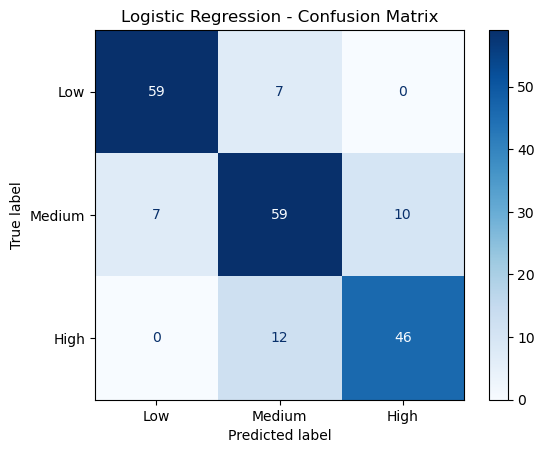


=== SVM ===
              precision    recall  f1-score   support

        High       0.92      0.81      0.86        58
         Low       0.89      0.86      0.88        66
      Medium       0.76      0.86      0.81        76

    accuracy                           0.84       200
   macro avg       0.86      0.84      0.85       200
weighted avg       0.85      0.84      0.85       200



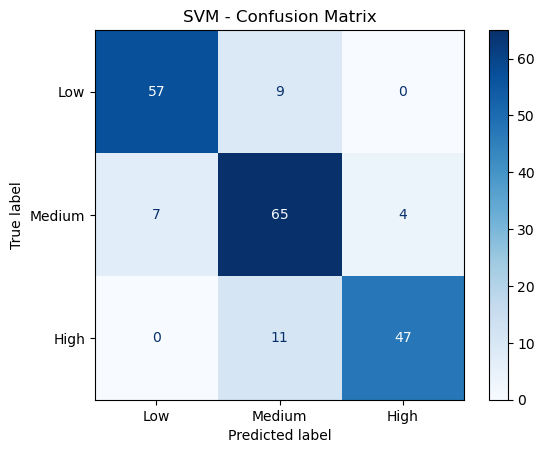


=== Random Forest ===
              precision    recall  f1-score   support

        High       1.00      0.98      0.99        58
         Low       0.99      1.00      0.99        66
      Medium       0.99      0.99      0.99        76

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200



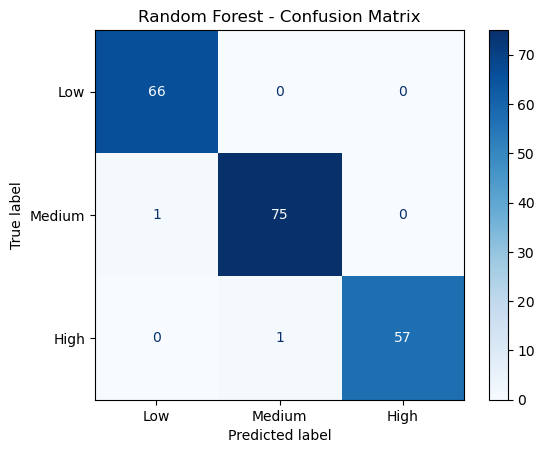

In [10]:
!pip install scikit-learn librosa pandas matplotlib

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/tong/Downloads/513final/features.csv')

feature_cols = ['rms', 'zcr', 'centroid', 'flux', 'tempo'] + \
               [f'mfcc_{i}' for i in range(1, 14)]

X = df[feature_cols]
y = df['energy_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM': SVC(kernel='rbf'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred, labels=['Low', 'Medium', 'High'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Low', 'Medium', 'High'])
    disp.plot(cmap='Blues')
    plt.title(f'{name} - Confusion Matrix')
    plt.show()